## **DATA DOWNLOAD & DATA PROCESSING WITH PySpark** 

<p style="text-align: justify;">
Wrote a PySpark script to automatically convert each Parquet file into a single monthly CSV, resulting in 120 CSV files across both taxi types.

In [1]:
# The following code is to hide Spark and Hadoop warning messages so the notebook output stays clean

import os
import logging

os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.driver.extraJavaOptions=-Dlog4j.configuration=file:log4j.properties pyspark-shell"

logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)

In [2]:
%%bash
echo "status = error" > log4j.properties
echo "name = Console" >> log4j.properties

In [3]:
import os
import glob
import shutil
from pyspark.sql import SparkSession

# NOTE:
# By default, PySpark saves each monthly dataset as a folder containing a single .csv part file.
# To get a clean, standalone CSV per month (e.g., yellow_2020-01.csv), the conversion process was
# modified to automatically extract each part file and save it separately

spark = (
    SparkSession.builder
    .appName("Convert_Parquet_to_CSV")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

base_path = "nyc_taxi_data"
yellow_path = os.path.join(base_path, "yellow")
green_path = os.path.join(base_path, "green")

def convert_parquet_to_csv_safe(folder_path, color):
    files = [f for f in os.listdir(folder_path) if f.endswith(".parquet")]
    for file in files:
        parquet_file = os.path.join(folder_path, file)
        ym = file.replace(".parquet", "").split("_")[-1]
        out_csv_name = f"{color}_{ym}.csv"
        out_csv_path = os.path.join(folder_path, out_csv_name)

        # If the file is already exists, just pass 
        if os.path.exists(out_csv_path):
            continue

        # If Spark already produced a '_csv' folder, extract part file
        csv_folder = parquet_file.replace(".parquet", "_csv")
        if os.path.exists(csv_folder):
            part_files = glob.glob(os.path.join(csv_folder, "part-*.csv"))
            if part_files:
                shutil.move(part_files[0], out_csv_path)
                shutil.rmtree(csv_folder)
                continue
                
        # Otherwise, read and convert parquet to csv normally
        print(f"Converting {file} → {out_csv_name}")
        df = spark.read.parquet(parquet_file)
        temp_folder = parquet_file.replace(".parquet", "_csv_temp")
        df.coalesce(1).write.option("header", "true").csv(temp_folder)

        part_file = glob.glob(os.path.join(temp_folder, "part-*.csv"))[0]
        shutil.move(part_file, out_csv_path)
        shutil.rmtree(temp_folder)
        print(f"Saved new CSV: {out_csv_name}")

convert_parquet_to_csv_safe(yellow_path, "yellow")
convert_parquet_to_csv_safe(green_path, "green")

print("All files converted to CSV")

spark.stop()

All files converted to CSV


In [4]:
# The following code is to check how many green and yellow .csv files exit

yellow_csvs = glob.glob("nyc_taxi_data/yellow/*.csv")
green_csvs = glob.glob("nyc_taxi_data/green/*.csv")

print(f"Yellow CSV files: {len(yellow_csvs)} found")
print(f"Green CSV files: {len(green_csvs)} found")

Yellow CSV files: 60 found
Green CSV files: 60 found


<p style="text-align: justify;">
Loaded all Yellow and Green taxi CSV files into PySpark and performed essential data cleaning. This involved standardizing column names, fixing timestamp formats, converting them to proper datetime objects, removing missing values, and filtering out invalid records such as zero distances, zero or negative fares, unrealistic passenger counts, and incorrect timestamps where drop-off occurred before pickup.

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, regexp_replace
import os

spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Data_Processing")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

base_path = "nyc_taxi_data"
yellow_path = os.path.join(base_path, "yellow")
green_path = os.path.join(base_path, "green")

# Load CSV files 
yellow_taxi_df = (
    spark.read.option("header", "true")
    .option("inferSchema", "true")
    .csv(os.path.join(yellow_path, "*.csv"))
)
green_taxi_df = (
    spark.read.option("header", "true")
    .option("inferSchema", "true")
    .csv(os.path.join(green_path, "*.csv"))
)

print("Raw Yellow Taxi Rows:", yellow_taxi_df.count())
print("Raw Green Taxi Rows:", green_taxi_df.count())

# Data Cleaning 

yellow_taxi_df = yellow_taxi_df.toDF(*[c.lower() for c in yellow_taxi_df.columns])
green_taxi_df = green_taxi_df.toDF(*[c.lower() for c in green_taxi_df.columns])

# I used regex for yellow_taxi timestamps formats 
yellow_taxi_df = (
    yellow_taxi_df
    .withColumn("tpep_pickup_datetime", regexp_replace(col("tpep_pickup_datetime"), "T", " "))
    .withColumn("tpep_dropoff_datetime", regexp_replace(col("tpep_dropoff_datetime"), "T", " "))
    .withColumn("tpep_pickup_datetime", regexp_replace(col("tpep_pickup_datetime"), r"\.\d+", ""))
    .withColumn("tpep_dropoff_datetime", regexp_replace(col("tpep_dropoff_datetime"), r"\.\d+", ""))
    .withColumn("tpep_pickup_datetime", to_timestamp(col("tpep_pickup_datetime"), "yyyy-MM-dd HH:mm:ss"))
    .withColumn("tpep_dropoff_datetime", to_timestamp(col("tpep_dropoff_datetime"), "yyyy-MM-dd HH:mm:ss"))
)

# Green timestamps 
green_taxi_df = (
    green_taxi_df
    .withColumn("lpep_pickup_datetime", to_timestamp(col("lpep_pickup_datetime")))
    .withColumn("lpep_dropoff_datetime", to_timestamp(col("lpep_dropoff_datetime")))
)

# Clean Yellow Taxi Data based on metadata dictionary
yellow_taxi_clean = (
    yellow_taxi_df
    .dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "fare_amount", "passenger_count"])
    .filter(
        (col("trip_distance") > 0)
        & (col("fare_amount") > 0)
        & (col("passenger_count") > 0)
        & (col("passenger_count") <= 6)
        & (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
    )
)

# Clean Green Taxi Data based on metadata dictionary
green_taxi_clean = (
    green_taxi_df
    .dropna(subset=["lpep_pickup_datetime", "lpep_dropoff_datetime", "trip_distance", "fare_amount", "passenger_count"])
    .filter(
        (col("trip_distance") > 0)
        & (col("fare_amount") > 0)
        & (col("passenger_count") > 0)
        & (col("passenger_count") <= 6)
        & (col("lpep_dropoff_datetime") > col("lpep_pickup_datetime"))
    )
)

print("Cleaned Yellow Taxi Rows:", yellow_taxi_clean.count())
print("Cleaned Green Taxi Rows:", green_taxi_clean.count())


Raw Yellow Taxi Rows: 174689444
Raw Green Taxi Rows: 5090611
Cleaned Yellow Taxi Rows: 125034721
Cleaned Green Taxi Rows: 3732754


In [6]:
# NOTE: 
# This cell is to check for irregular timestamp formats (e.g., "/", "T", or ".000")
# before deciding whether regex-based cleaning was necessary

yellow_slash = yellow_taxi_df.filter(col("tpep_pickup_datetime").contains("/")).count()
green_slash  = green_taxi_df.filter(col("lpep_pickup_datetime").contains("/")).count()

yellow_T = yellow_taxi_df.filter(col("tpep_pickup_datetime").contains("T")).count()
green_T  = green_taxi_df.filter(col("lpep_pickup_datetime").contains("T")).count()

yellow_ms = yellow_taxi_df.filter(col("tpep_pickup_datetime").contains(".")).count()
green_ms  = green_taxi_df.filter(col("lpep_pickup_datetime").contains(".")).count()

print("-----Timestamp formats-----")
print(f"Yellow Taxi with '/' : {yellow_slash}")
print(f"Green  Taxi with '/' : {green_slash}")
print(f"Yellow Taxi with 'T' : {yellow_T}")
print(f"Green  Taxi with 'T' : {green_T}")
print(f"Yellow Taxi with '.000' : {yellow_ms}")
print(f"Green  Taxi with '.000' : {green_ms}")


-----Timestamp formats-----
Yellow Taxi with '/' : 0
Green  Taxi with '/' : 0
Yellow Taxi with 'T' : 0
Green  Taxi with 'T' : 0
Yellow Taxi with '.000' : 0
Green  Taxi with '.000' : 0


In [7]:
# Visualisation of a sample of the cleaned dataset for both yellow and green taxi records 

yellow_selected_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount"
]

green_selected_cols = [
    "lpep_pickup_datetime",
    "lpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "total_amount"
]

print("\n------Cleaned Yellow Taxi Samples------")
yellow_taxi_clean.select(yellow_selected_cols).show(5, truncate=False)

print("\n------Cleaned Green Taxi Samples------")
green_taxi_clean.select(green_selected_cols).show(5, truncate=False)


------Cleaned Yellow Taxi Samples------
+--------------------+---------------------+---------------+-------------+-----------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|fare_amount|total_amount|
+--------------------+---------------------+---------------+-------------+-----------+------------+
|2020-01-01 00:28:15 |2020-01-01 00:33:03  |1.0            |1.2          |6.0        |11.27       |
|2020-01-01 00:35:39 |2020-01-01 00:43:04  |1.0            |1.2          |7.0        |12.3        |
|2020-01-01 00:55:11 |2020-01-01 01:12:03  |2.0            |2.4          |12.0       |17.55       |
|2020-01-01 00:56:27 |2020-01-01 01:21:44  |1.0            |3.3          |17.0       |24.95       |
|2020-01-01 00:21:54 |2020-01-01 00:27:31  |1.0            |1.07         |6.0        |11.76       |
+--------------------+---------------------+---------------+-------------+-----------+------------+
only showing top 5 rows


------Cleaned Green Taxi Samples-

## **SAVE DATA INTO SQLite Database**

In [8]:
import sqlite3

def save_sample(df, db_name, table_name, sample_size=500000):
    """
    Saves a sample of the Spark DataFrame into SQLite to avoid memory overflow.
    """
    conn = sqlite3.connect(db_name)
    sample_df = df.limit(sample_size).toPandas()
    
    # Save into SQLite
    sample_df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    print(f"Saved {sample_size} rows from {table_name} into {db_name}")

# Save Yellow and Green Taxi samples
save_sample(yellow_taxi_clean, "nyc_yellow_taxi.db", "yellow_taxi", sample_size=500000)
save_sample(green_taxi_clean, "nyc_green_taxi.db", "green_taxi", sample_size=500000)


Saved 500000 rows from yellow_taxi into nyc_yellow_taxi.db
Saved 500000 rows from green_taxi into nyc_green_taxi.db
Sample backup completed.


In [9]:
import pandas as pd

conn = sqlite3.connect("nyc_yellow_taxi.db")
print("Yellow rows:", pd.read_sql_query("SELECT COUNT(*) FROM yellow_taxi", conn))
conn.close()

conn = sqlite3.connect("nyc_green_taxi.db")
print("Green rows:", pd.read_sql_query("SELECT COUNT(*) FROM green_taxi", conn))
conn.close()

Yellow rows:    COUNT(*)
0    500000
Green rows:    COUNT(*)
0    500000


## **EXPLORATORY DATA ANALYSIS WITH PySpark**

The goal was to perform some exploratory analysis to gain insights into the dataset.

**1. Top 10 pickup locations based on the number of trips**

In [10]:
from pyspark.sql.functions import count, col

print("Yellow Taxi: Top 10 Pickup Locations")
yellow_taxi_clean.groupBy("PULocationID") \
    .agg(count("*").alias("trip_count")) \
    .orderBy(col("trip_count").desc()) \
    .limit(10) \
    .show()

print("Green Taxi: Top 10 Pickup Locations")
green_taxi_clean.groupBy("PULocationID") \
    .agg(count("*").alias("trip_count")) \
    .orderBy(col("trip_count").desc()) \
    .limit(10) \
    .show()


Yellow Taxi: Top 10 Pickup Locations
+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|         132|   7036379|
|         237|   5243714|
|         161|   5195025|
|         236|   5005072|
|         138|   4569516|
|         186|   4479962|
|         162|   4248303|
|         142|   4105223|
|         230|   3772357|
|         170|   3677518|
+------------+----------+

Green Taxi: Top 10 Pickup Locations
+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|          74|    665607|
|          75|    481528|
|          41|    255652|
|         166|    195341|
|          95|    171345|
|          82|    145608|
|          42|    133817|
|          43|    126199|
|         244|    119581|
|          97|    116104|
+------------+----------+



**2. Trip distribution across hours of the day**

In [11]:
from pyspark.sql.functions import hour, count

# Yellow Taxi - trips by hour
yellow_hourly = (
    yellow_taxi_clean
    .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
    .groupBy("pickup_hour")
    .agg(count("*").alias("trip_count"))
    .orderBy("pickup_hour")
)

print("Yellow Taxi: Trips by Hour")
yellow_hourly.show(24)

# Green Taxi - trips by hour
green_hourly = (
    green_taxi_clean
    .withColumn("pickup_hour", hour("lpep_pickup_datetime"))
    .groupBy("pickup_hour")
    .agg(count("*").alias("trip_count"))
    .orderBy("pickup_hour")
)

print("Green Taxi: Trips by Hour")
green_hourly.show(24)


Yellow Taxi: Trips by Hour
+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|          0|   3463984|
|          1|   2257126|
|          2|   1466424|
|          3|    970366|
|          4|    649186|
|          5|    775351|
|          6|   1919121|
|          7|   3622406|
|          8|   4806960|
|          9|   5352266|
|         10|   5854407|
|         11|   6292168|
|         12|   6804615|
|         13|   7041113|
|         14|   7624226|
|         15|   7829666|
|         16|   7776851|
|         17|   8409751|
|         18|   8737862|
|         19|   7852820|
|         20|   7034336|
|         21|   6989850|
|         22|   6449932|
|         23|   5053934|
+-----------+----------+

Green Taxi: Trips by Hour
+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|          0|     70616|
|          1|     48248|
|          2|     32271|
|          3|     25153|
|          4|     20679|
|          5|     21632|
|          6|     585

**3. Average fare amount by distance intervals**

In [12]:
from pyspark.sql.functions import when, col, avg

yellow_bins = (
    yellow_taxi_clean
    .withColumn(
        "distance_bin",
        when(col("trip_distance") < 1, "0-1 miles")
        .when((col("trip_distance") >= 1) & (col("trip_distance") < 2), "1-2 miles")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2-5 miles")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "5-10 miles")
        .otherwise("10+ miles")
    )
    .groupBy("distance_bin")
    .agg(avg("fare_amount").alias("avg_fare"))
    .orderBy("distance_bin")
)

print("Yellow Taxi: Average Fare by Distance Bin")
yellow_bins.show()

green_bins = (
    green_taxi_clean
    .withColumn(
        "distance_bin",
        when(col("trip_distance") < 1, "0-1 miles")
        .when((col("trip_distance") >= 1) & (col("trip_distance") < 2), "1-2 miles")
        .when((col("trip_distance") >= 2) & (col("trip_distance") < 5), "2-5 miles")
        .when((col("trip_distance") >= 5) & (col("trip_distance") < 10), "5-10 miles")
        .otherwise("10+ miles")
    )
    .groupBy("distance_bin")
    .agg(avg("fare_amount").alias("avg_fare"))
    .orderBy("distance_bin")
)

print("Green Taxi: Average Fare by Distance Bin")
green_bins.show()


Yellow Taxi: Average Fare by Distance Bin
+------------+------------------+
|distance_bin|          avg_fare|
+------------+------------------+
|   1-2 miles| 9.895023623086917|
|   10+ miles|57.241830197337805|
|   2-5 miles| 16.00783358955247|
|  5-10 miles|29.397316673027255|
+------------+------------------+

Green Taxi: Average Fare by Distance Bin
+------------+------------------+
|distance_bin|          avg_fare|
+------------+------------------+
|   0-1 miles| 6.667503848282578|
|   1-2 miles| 9.173544547435554|
|   10+ miles| 57.73880017356017|
|   2-5 miles| 15.52734264848894|
|  5-10 miles|28.109505933937026|
+------------+------------------+



**4. Trip volume trends by year and month**

In [13]:
from pyspark.sql.functions import year, month, count

print("Yellow Taxi: Trips by Year and Month")

yellow_trends = (
    yellow_taxi_clean
    .withColumn("year", year("tpep_pickup_datetime"))
    .withColumn("month", month("tpep_pickup_datetime"))
    .groupBy("year", "month")
    .agg(count("*").alias("trip_count"))
    .orderBy("year", "month")
)

yellow_trends.show(20)

print("Green Taxi: Trips by Year and Month")

green_trends = (
    green_taxi_clean
    .withColumn("year", year("lpep_pickup_datetime"))
    .withColumn("month", month("lpep_pickup_datetime"))
    .groupBy("year", "month")
    .agg(count("*").alias("trip_count"))
    .orderBy("year", "month")
)

green_trends.show(20)

Yellow Taxi: Trips by Year and Month
+----+-----+----------+
|year|month|trip_count|
+----+-----+----------+
|2001|    1|        10|
|2001|    8|         1|
|2002|   10|       292|
|2002|   12|        18|
|2003|    1|        17|
|2004|    4|         1|
|2008|   12|       140|
|2009|    1|       251|
|2011|    1|         1|
|2011|    2|         2|
|2014|   11|         1|
|2019|   12|        96|
|2020|    1|   4592271|
|2020|    2|   4509398|
|2020|    3|   2168432|
|2020|    4|    153111|
|2020|    5|    206264|
|2020|    6|    363691|
|2020|    7|    532372|
|2020|    8|    679452|
+----+-----+----------+
only showing top 20 rows

Green Taxi: Trips by Year and Month
+----+-----+----------+
|year|month|trip_count|
+----+-----+----------+
|2008|   12|         6|
|2009|    1|        38|
|2010|    9|         5|
|2019|   12|        16|
|2020|    1|    314457|
|2020|    2|    303213|
|2020|    3|    167576|
|2020|    4|     22704|
|2020|    5|     28898|
|2020|    6|     35327|
|2020|    7| 

**5. Top 5 drop-off locations with the highest average fare**

In [14]:
yellow_taxi_clean.createOrReplaceTempView("yellow_taxi")
green_taxi_clean.createOrReplaceTempView("green_taxi")

print("Yellow Taxi: Top 5 Drop-off Locations with Highest Avg Fare")
spark.sql("""
    SELECT DOLocationID, AVG(fare_amount) AS avg_fare
    FROM yellow_taxi
    GROUP BY DOLocationID
    ORDER BY avg_fare DESC
    LIMIT 5
""").show()

print("Green Taxi: Top 5 Drop-off Locations with Highest Avg Fare")
spark.sql("""
    SELECT DOLocationID, AVG(fare_amount) AS avg_fare
    FROM green_taxi
    GROUP BY DOLocationID
    ORDER BY avg_fare DESC
    LIMIT 5
""").show()


Yellow Taxi: Top 5 Drop-off Locations with Highest Avg Fare
+------------+------------------+
|DOLocationID|          avg_fare|
+------------+------------------+
|         204|101.52980501392761|
|          84|101.34806666666667|
|          44| 94.80415100350427|
|         265| 93.10552635676873|
|         110| 93.02857142857144|
+------------+------------------+

Green Taxi: Top 5 Drop-off Locations with Highest Avg Fare
+------------+------------------+
|DOLocationID|          avg_fare|
+------------+------------------+
|         204|102.43636363636364|
|           1| 96.99321782178218|
|          23| 77.58150814053127|
|         176|          75.81875|
|           5| 74.83383084577113|
+------------+------------------+



**6. Number of trips taken on weekends (Saturday and Sunday) versus weekdays**

In [15]:
from pyspark.sql.functions import dayofweek, count

yellow_week = (
    yellow_taxi_clean
    .withColumn("dow", dayofweek("tpep_pickup_datetime"))
    .withColumn("day_type",
                when(col("dow").isin(1, 7), "Weekend").otherwise("Weekday"))
    .groupBy("day_type")
    .agg(count("*").alias("trip_count"))
)

print("Yellow Taxi: Weekday vs Weekend Trips")
yellow_week.show()

green_week = (
    green_taxi_clean
    .withColumn("dow", dayofweek("lpep_pickup_datetime"))
    .withColumn("day_type",
                when(col("dow").isin(1, 7), "Weekend").otherwise("Weekday"))
    .groupBy("day_type")
    .agg(count("*").alias("trip_count"))
)

print("Green Taxi: Weekday vs Weekend Trips")
green_week.show()

Yellow Taxi: Weekday vs Weekend Trips
+--------+----------+
|day_type|trip_count|
+--------+----------+
| Weekday|  91333659|
| Weekend|  33701062|
+--------+----------+

Green Taxi: Weekday vs Weekend Trips
+--------+----------+
|day_type|trip_count|
+--------+----------+
| Weekday|   2805448|
| Weekend|    927306|
+--------+----------+



**7. Average fare for trips where the distance > 10 miles**

In [16]:
from pyspark.sql.functions import col, avg

print("Yellow Taxi: Avg Fare for Distance > 10 miles")
yellow_taxi_clean.filter(col("trip_distance") > 10) \
    .agg(avg("fare_amount").alias("avg_fare_over_10_miles")) \
    .show()

print("Green Taxi: Avg Fare for Distance > 10 miles")
green_taxi_clean.filter(col("trip_distance") > 10) \
    .agg(avg("fare_amount").alias("avg_fare_over_10_miles")) \
    .show()

Yellow Taxi: Avg Fare for Distance > 10 miles
+----------------------+
|avg_fare_over_10_miles|
+----------------------+
|      60.2794217754085|
+----------------------+

Green Taxi: Avg Fare for Distance > 10 miles
+----------------------+
|avg_fare_over_10_miles|
+----------------------+
|     57.81161675397806|
+----------------------+



**8. Most frequently used payment method**

In [17]:
from pyspark.sql.functions import col, count, when

payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

payment_expr = """
    CASE 
        WHEN payment_type = 1 THEN 'Credit Card'
        WHEN payment_type = 2 THEN 'Cash'
        WHEN payment_type = 3 THEN 'No Charge'
        WHEN payment_type = 4 THEN 'Dispute'
        WHEN payment_type = 5 THEN 'Unknown'
        WHEN payment_type = 6 THEN 'Voided Trip'
        ELSE 'Other'
    END AS payment_method
"""

print("=== Yellow Taxi: Most Frequently Used Payment Method ===")
spark.sql(f"""
    SELECT {payment_expr}, COUNT(*) AS trip_count
    FROM yellow_taxi
    GROUP BY payment_method
    ORDER BY trip_count DESC
    LIMIT 1
""").show(truncate=False)

print("=== Green Taxi: Most Frequently Used Payment Method ===")
spark.sql(f"""
    SELECT {payment_expr}, COUNT(*) AS trip_count
    FROM green_taxi
    GROUP BY payment_method
    ORDER BY trip_count DESC
    LIMIT 1
""").show(truncate=False)


=== Yellow Taxi: Most Frequently Used Payment Method ===
+--------------+----------+
|payment_method|trip_count|
+--------------+----------+
|Credit Card   |101202171 |
+--------------+----------+

=== Green Taxi: Most Frequently Used Payment Method ===
+--------------+----------+
|payment_method|trip_count|
+--------------+----------+
|Credit Card   |2295983   |
+--------------+----------+



## **FEATURE ENGINEERING**

The goal was to create new features to prepare the Yellow and Green Taxi datasets for machine learning.

In [18]:
from pyspark.sql.functions import (
    hour, dayofweek, month,
    unix_timestamp, col, when
)
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Extract time based-features (Hour, Day of Week, Month)

yellow_fe = (
    yellow_taxi_clean
    .withColumn("pickup_hour", hour("tpep_pickup_datetime"))
    .withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_month", month("tpep_pickup_datetime"))
)

green_fe = (
    green_taxi_clean
    .withColumn("pickup_hour", hour("lpep_pickup_datetime"))
    .withColumn("pickup_dayofweek", dayofweek("lpep_pickup_datetime"))
    .withColumn("pickup_month", month("lpep_pickup_datetime"))
)

# Calculate the trip duration in minutes (dropoff_datetime - pickup_datetime)

yellow_fe = yellow_fe.withColumn(
    "trip_duration_min",
    (unix_timestamp("tpep_dropoff_datetime") - unix_timestamp("tpep_pickup_datetime")) / 60
)

green_fe = green_fe.withColumn(
    "trip_duration_min",
    (unix_timestamp("lpep_dropoff_datetime") - unix_timestamp("lpep_pickup_datetime")) / 60
)

# Categorical bins based on the trip_distance

yellow_fe = yellow_fe.withColumn(
    "distance_bin",
    when(col("trip_distance") <= 1, "0-1 miles")
    .when(col("trip_distance") <= 2, "1-2 miles")
    .when(col("trip_distance") <= 5, "2-5 miles")
    .when(col("trip_distance") <= 10, "5-10 miles")
    .otherwise("10+ miles")
)

green_fe = green_fe.withColumn(
    "distance_bin",
    when(col("trip_distance") <= 1, "0-1 miles")
    .when(col("trip_distance") <= 2, "1-2 miles")
    .when(col("trip_distance") <= 5, "2-5 miles")
    .when(col("trip_distance") <= 10, "5-10 miles")
    .otherwise("10+ miles")
)

# One-hot encoding

categorical_cols = ["payment_type", "distance_bin"] # Columns to encode

stages = []

for c in categorical_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c + "_index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCols=[c + "_index"], outputCols=[c + "_ohe"])
    stages += [indexer, encoder]

pipeline = Pipeline(stages=stages)

yellow_model = pipeline.fit(yellow_fe)
yellow_final = yellow_model.transform(yellow_fe)

green_model = pipeline.fit(green_fe)
green_final = green_model.transform(green_fe)

print("\nYellow Taxi Feature Table")
yellow_final.select(
    "pickup_hour", "pickup_dayofweek", "pickup_month",
    "trip_duration_min", "distance_bin",
    "payment_type", "payment_type_ohe"
).show(10, truncate=False)

print("\nGreen Taxi Feature Table")
green_final.select(
    "pickup_hour", "pickup_dayofweek", "pickup_month",
    "trip_duration_min", "distance_bin",
    "payment_type", "payment_type_ohe"
).show(10, truncate=False)



Yellow Taxi Feature Table
+-----------+----------------+------------+------------------+------------+------------+----------------+
|pickup_hour|pickup_dayofweek|pickup_month|trip_duration_min |distance_bin|payment_type|payment_type_ohe|
+-----------+----------------+------------+------------------+------------+------------+----------------+
|0          |4               |1           |4.8               |0-1 miles   |1           |(5,[0],[1.0])   |
|0          |4               |1           |7.416666666666667 |0-1 miles   |1           |(5,[0],[1.0])   |
|0          |4               |1           |16.866666666666667|1-2 miles   |1           |(5,[0],[1.0])   |
|0          |4               |1           |25.283333333333335|2-5 miles   |1           |(5,[0],[1.0])   |
|0          |4               |1           |5.616666666666666 |0-1 miles   |1           |(5,[0],[1.0])   |
|0          |4               |1           |37.333333333333336|5-10 miles  |1           |(5,[0],[1.0])   |
|0          |4     

## **MACHINE LEARNING WITH Spark ML**
<p style="text-align: justify;">
Built machine learning models to predict taxi fare amounts using the engineered features from the previous feature engineering step. All selected numerical and one-hot encoded features were assembled into a single feature vector using VectorAssembler. Given the size of the NYC Taxi dataset, training models on the full data caused memory issues and long processing times. To keep training manageable while still preserving overall patterns, a random sample was used: 10% for Yellow Taxi and 20% for Green Taxi. The Yellow dataset was considerably heavier in terms of RAM and processing load, hence the smaller sampling ratio. These smaller subsets were still large enough to represent the overall patterns while making the training process much more manageable.
</p>

<p style="text-align: justify;">
Once the data was ready, both datasets were split into training and testing sets using an 80/20 split. Three regression models were trained — Linear Regression, Random Forest, and Decision Tree — chosen because each captures patterns differently, making comparison useful for identifying the best fit. Model performance was evaluated using RMSE, MAE, and R², which made it straightforward to compare accuracy across models.
</p>

In [19]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

numeric_cols = [
    "trip_distance",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "trip_duration_min",
    "passenger_count"
]

for c in numeric_cols:
    yellow_final = yellow_final.withColumn(c, col(c).cast("double"))
    green_final  = green_final.withColumn(c, col(c).cast("double"))
    
    
yellow_final = yellow_final.withColumn("fare_amount", col("fare_amount").cast("double"))
green_final  = green_final.withColumn("fare_amount", col("fare_amount").cast("double"))

yellow_sample = yellow_final.sample(withReplacement=False, fraction=0.10, seed=42)
green_sample  = green_final.sample(withReplacement=False, fraction=0.20, seed=42)

# Prepare data

feature_cols = [
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "trip_duration_min",
    "trip_distance",
    "passenger_count",
    "payment_type_ohe",
    "distance_bin_ohe"
]

label_col = "fare_amount"

def prepare_ml_data(df):
    cols_to_keep = [label_col] + feature_cols
    df_model = df.select(*cols_to_keep)
    df_model = df_model.na.drop(subset=cols_to_keep)
    return df_model

yellow_ml = prepare_ml_data(yellow_sample)
green_ml  = prepare_ml_data(green_sample)

# Training 

yellow_train, yellow_test = yellow_ml.randomSplit([0.8, 0.2], seed=42)
green_train,  green_test  = green_ml.randomSplit([0.8, 0.2], seed=42)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# Three regression models 

lr = LinearRegression(featuresCol="features", labelCol=label_col)
rf = RandomForestRegressor(featuresCol="features", labelCol=label_col, numTrees=20, maxDepth=8)
dt = DecisionTreeRegressor(labelCol=label_col, featuresCol="features", maxDepth=10)


models = [
    ("Linear Regression", lr),
    ("Random Forest", rf),
    ("Decision Tree", dt)
]

evaluator_rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2")


print("Results for yellow taxi")

yellow_best_rmse = float("inf")
yellow_best_model = None
yellow_best_name = None

for name, model in models:
    pipeline = Pipeline(stages=[assembler, model])
    fitted = pipeline.fit(yellow_train)
    preds = fitted.transform(yellow_test)

    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    r2   = evaluator_r2.evaluate(preds)

    print(f"\n{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE : {mae:.3f}")
    print(f"  R²  : {r2:.3f}")

    if rmse < yellow_best_rmse:
        yellow_best_rmse = rmse
        yellow_best_model = fitted
        yellow_best_name = name

print(f"\nBest yellow model → {yellow_best_name} (RMSE={yellow_best_rmse:.3f})")

print("Results for green taxi")

green_best_rmse = float("inf")
green_best_model = None
green_best_name = None

for name, model in models:
    pipeline = Pipeline(stages=[assembler, model])
    fitted = pipeline.fit(green_train)
    preds = fitted.transform(green_test)

    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    r2   = evaluator_r2.evaluate(preds)

    print(f"\n{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE : {mae:.3f}")
    print(f"  R²  : {r2:.3f}")

    if rmse < green_best_rmse:
        green_best_rmse = rmse
        green_best_model = fitted
        green_best_name = name

print(f"\nBest green model → {green_best_name} (RMSE={green_best_rmse:.3f})")


Results for yellow taxi

Linear Regression
  RMSE: 11.139
  MAE : 4.300
  R²  : 0.616

Random Forest
  RMSE: 9.788
  MAE : 3.081
  R²  : 0.704

Decision Tree
  RMSE: 10.141
  MAE : 3.039
  R²  : 0.682

Best yellow model → Random Forest (RMSE=9.788)
Results for green taxi

Linear Regression
  RMSE: 8.910
  MAE : 3.801
  R²  : 0.603

Random Forest
  RMSE: 7.800
  MAE : 2.817
  R²  : 0.695

Decision Tree
  RMSE: 8.698
  MAE : 2.706
  R²  : 0.621

Best green model → Random Forest (RMSE=7.800)


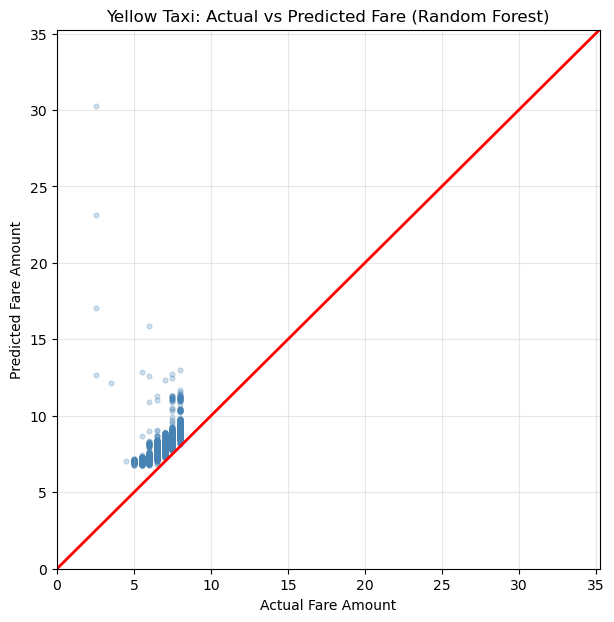

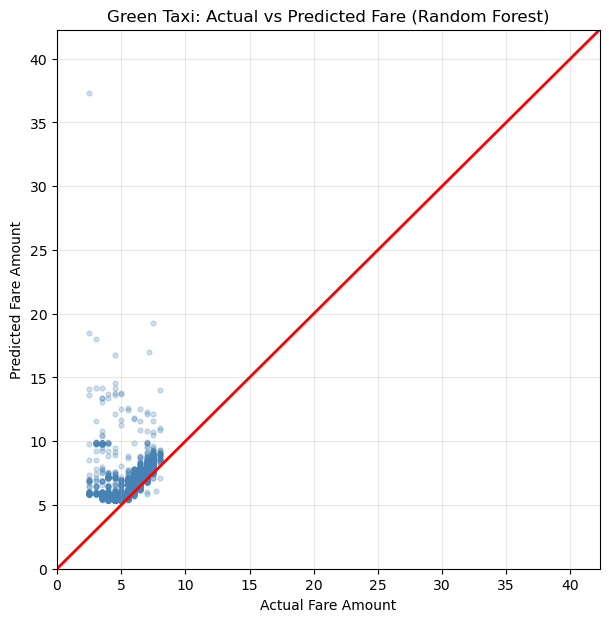

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_results(sample_df, best_name, title_suffix):

    max_val = max(sample_df["fare_amount"].max(), sample_df["prediction"].max())
    
    plt.figure(figsize=(7,7))
    plt.scatter(
        sample_df["fare_amount"],
        sample_df["prediction"],
        alpha=0.25,
        s=12,
        color="steelblue"
    )
    
    plt.xlim(0, max_val + 5)  
    plt.ylim(0, max_val + 5)


    plt.plot([0, max_val + 5], [0, max_val + 5], color='red', linewidth=2)

    plt.xlabel("Actual Fare Amount")
    plt.ylabel("Predicted Fare Amount")
    plt.title(f"{title_suffix}: Actual vs Predicted Fare ({best_name})")
    plt.grid(alpha=0.3)
    plt.show()


# Yellow Taxi
yellow_preds = yellow_best_model.transform(yellow_test)
yellow_sample = yellow_preds.select("fare_amount", "prediction").limit(5000).toPandas()
plot_results(yellow_sample, yellow_best_name, "Yellow Taxi")

# Green Taxi
green_preds = green_best_model.transform(green_test)
green_sample = green_preds.select("fare_amount", "prediction").limit(5000).toPandas()
plot_results(green_sample, green_best_name, "Green Taxi")

## MODEL EVALUATION & LIMITATIONS

Based on the evaluation metrics, the models were able to predict fare amounts only moderately well. For both Yellow and Green taxi datasets, the Random Forest model performed the best, with the lowest RMSE (Yellow taxi: 9.788; Green taxi: 7.80) and the highest R² (Yellow taxi: 0.704; Green taxi: 0.695). This means it captured the relationship between the features and the fare better than Linear Regression and Decision Trees.

<p style="text-align: justify;">
However, even the best model still showed noticeable prediction errors, especially for higher fare amounts. This was also visible in the scatter plots, where the predicted values were clustered tightly on the left side. This happened mainly because only 10% of the yellow taxi data and 20% of the green taxi data were used. Since high-fare trips were already rare in the full dataset, most of them disappeared completely in the sample. As a result, the model mainly learned low-fare patterns and struggled whenever the actual fare was higher. This sampling effect explains why the predictions remained concentrated in a narrow range. A surprise was how poorly the Decision Tree performed on the sampled data, even though its RMSE was close to Random Forest in earlier runs. With more data or the full dataset, it is possible that the Decision Tree model would have performed much better — it struggled here because it didn't have enough examples of rare patterns to build meaningful splits. Finally, with more time or computing resources, several improvements could be made. First, training on a larger and more diverse sample — especially trips with long distances or unusually high fares, since these patterns were under-represented in the smaller subset used — would likely help. Also, using stratified sampling instead of simple random sampling would likely capture higher fare levels better, since it would force the sample to include a more balanced share of rare high-fare trips. Overall, the models perform reasonably well, but their accuracy is naturally limited by the reduced dataset size.
</p>